# DevOps Deployment Failure Prediction
### CrowdStrike 2024 Global Outage – SEAD Case Study

This project simulates DevOps deployment risks similar to the CrowdStrike outage using machine learning.

The goal is to predict whether a software update may cause a system failure based on testing coverage, validation checks, rollout strategy, rollback availability, and monitoring strength.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
np.random.seed(42)

data = {
    "test_coverage": np.random.randint(40,100,200),
    "validation_pass": np.random.randint(0,2,200),
    "rollout_type": np.random.randint(0,2,200),  # 0 = global, 1 = staged
    "rollback_available": np.random.randint(0,2,200),
    "monitoring_score": np.random.randint(1,10,200)
}

df = pd.DataFrame(data)

# Target variable (simulate failure risk)
df["failure_occurred"] = (
    (df["test_coverage"] < 70) |
    (df["validation_pass"] == 0) |
    (df["rollout_type"] == 0) |
    (df["rollback_available"] == 0) |
    (df["monitoring_score"] < 5)
).astype(int)

df.head()

,test_coverage,validation_pass,rollout_type,rollback_available,monitoring_score,failure_occurred
0,78,0,1,0,9,1
1,91,0,1,1,7,1
2,68,0,1,1,4,1
3,54,1,1,0,3,1
4,82,1,0,1,5,1


## Dataset Description

The dataset simulates DevOps release metrics.

Features used in this project:

• test_coverage – percentage of regression test coverage  
• validation_pass – build validation status (0 = fail, 1 = pass)  
• rollout_type – deployment strategy (0 = global rollout, 1 = staged rollout)  
• rollback_available – rollback mechanism availability  
• monitoring_score – system observability strength  

Target Variable:

• failure_occurred – indicates whether deployment resulted in system failure.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   test_coverage       200 non-null    int64
 1   validation_pass     200 non-null    int64
 2   rollout_type        200 non-null    int64
 3   rollback_available  200 non-null    int64
 4   monitoring_score    200 non-null    int64
 5   failure_occurred    200 non-null    int64
dtypes: int64(6)
memory usage: 9.5 KB


In [4]:
df.describe()

,test_coverage,validation_pass,rollout_type,rollback_available,monitoring_score,failure_occurred
count,200.00000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,69.32500,0.530000,0.550000,0.49500,4.795000,0.945000
std,17.39027,0.500352,0.498742,0.50123,2.556492,0.228552
min,40.00000,0.000000,0.000000,0.00000,1.000000,0.000000
25%,54.00000,0.000000,0.000000,0.00000,3.000000,1.000000
50%,68.50000,1.000000,1.000000,0.00000,5.000000,1.000000
75%,83.00000,1.000000,1.000000,1.00000,7.000000,1.000000
max,99.00000,1.000000,1.000000,1.00000,9.000000,1.000000


In [5]:
X = df.drop("failure_occurred", axis=1)
y = df["failure_occurred"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [8]:
y_pred = model.predict(X_test)

In [9]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.975

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.97      1.00      0.99        36

    accuracy                           0.97        40
   macro avg       0.99      0.88      0.92        40
weighted avg       0.98      0.97      0.97        40



## Model Performance

The Random Forest model predicts deployment failures based on DevOps risk factors.

Key insights:

• Low test coverage increases failure probability  
• Global rollout without staging increases system risk  
• Lack of rollback mechanisms makes recovery difficult  
• Weak monitoring delays detection of failures  

These factors closely resemble the root causes of the CrowdStrike outage.

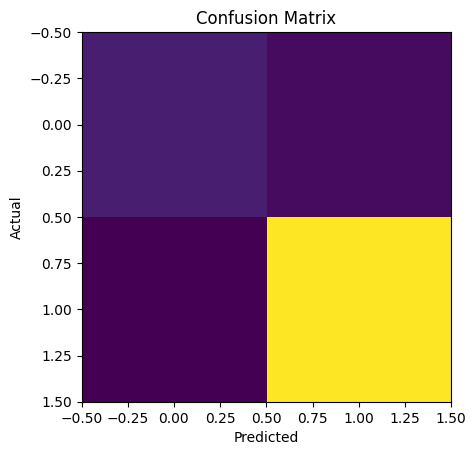

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

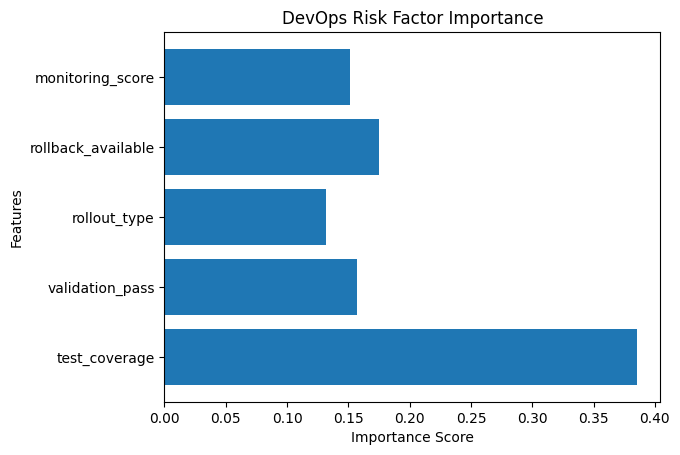

In [11]:
importance = model.feature_importances_

plt.figure()
plt.barh(X.columns, importance)
plt.title("DevOps Risk Factor Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

## Feature Importance Analysis

The model highlights which DevOps factors contribute most to deployment failures.

Important observations:

• Test coverage is a critical factor for stability  
• Rollback availability significantly reduces risk  
• Staged rollout strategies improve deployment safety  
• Monitoring systems help detect anomalies early

## Conclusion

This project demonstrates how software deployment failures can be predicted using DevOps risk indicators.

The study highlights the importance of:

• comprehensive testing  
• staged deployment strategies  
• automated rollback mechanisms  
• robust monitoring systems

Applying these principles can prevent large-scale incidents like the CrowdStrike outage.